In [1]:
#!/usr/bin/env python
"""
ntol_sweep.py
Sweep over fractional distance tolerance (ntol) values and compute:
  1. Number of surviving samples after dL masking
  2. 95% upper limit on Mc
  3. Error on the 95% UL
  4. (Optional) Enterprise comparison

Run on Thorny Flat:
  python ntol_sweep.py

Outputs:
  ntol_sweep_results.pdf   -- 3-panel figure
  ntol_sweep_results.csv   -- table of results
"""

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os


In [2]:
# ============================================================
# CONFIG - edit these paths for your setup
# ============================================================
QCW_H5 = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_narrow_UL_fixed_gamma_17_dec_2025_outfile.h5"
ENT_H5 = "/scratch/na00078/projects/IPTA_MDC2/h5_files/core_single_MDC2_DS1.h5"
TARGET_DL = 75.4  # Mpc

# ntol values to sweep (fractional, so 0.01 = 1%, 0.10 = 10%)
NTOL_VALUES = np.array([0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50])

# Constants
MEGAPARSEC = 3.086e+22 #meter
SPEED_OF_LIGHT = 299792458.0  # m/s
T_SUN = 1.327124400e20 / SPEED_OF_LIGHT**3  # G*M_sun/c^3 in seconds

FIRST_N_PARAM = 8
BURNIN = 0
THIN = 1
Q = 0.95  # credible level for UL



In [3]:
# ============================================================
# 1. Load QuickCW samples
# ============================================================
print("Loading QuickCW samples...")
with h5py.File(QCW_H5, "r") as f:
    samples_cold = f["samples_cold"][:, :, :FIRST_N_PARAM]

# Extract physical quantities (all 1e8 samples)
h_amp = 10**samples_cold[0][BURNIN::THIN, 4]   # linear strain
fff   = 10**samples_cold[0][BURNIN::THIN, 3]   # linear frequency (Hz)
mmm   = 10**samples_cold[0][BURNIN::THIN, 5]   # linear chirp mass (Msun)
log10_mc = samples_cold[0][BURNIN::THIN, 5]     # log10 chirp mass

N_total = len(h_amp)
print(f"Total samples: {N_total:,}")

# Compute derived dL for every sample (in Mpc)
# Formula in geometric units gives seconds; multiply by c/Mpc to get Mpc
dL_all = 2.0 * (mmm * T_SUN)**(5./3.) * (np.pi * fff)**(2./3.) / h_amp * SPEED_OF_LIGHT / MEGAPARSEC
print(f"dL range: {dL_all.min():.4e} -- {dL_all.max():.4e} Mpc")

Loading QuickCW samples...
Total samples: 100,000,000
dL range: 3.4020e-03 -- 3.0608e+08 Mpc


In [4]:
# ============================================================
# 2. Load Enterprise UL for comparison
# ============================================================
ent_mc_UL = None
ent_mc_UL_err = None
try:
    print("Loading Enterprise samples...")
    with h5py.File(ENT_H5, "r") as f:
        e_samples = f["chain"][...]
        e_params  = [p.decode("utf-8") for p in f["params"][...]]
        burn      = f["metadata/burn"][()]
    e_samples = e_samples[burn:, :]
    idx_mc = e_params.index("log10_mc")
    ent_mc = 10**(e_samples[:, idx_mc])
    N_ent  = len(ent_mc)
    ent_mc_UL = np.quantile(ent_mc, Q)
    kde_ent   = gaussian_kde(ent_mc)
    f_q_ent   = kde_ent.evaluate([ent_mc_UL])[0]
    ent_mc_UL_err = np.sqrt(Q * (1 - Q)) / (f_q_ent * np.sqrt(N_ent))
    ent_mc_log_UL = np.log10(ent_mc_UL)
    ent_mc_log_UL_err = ent_mc_UL_err / (ent_mc_UL * np.log(10))
    print(f"Enterprise UL: log10(Mc) = {ent_mc_log_UL:.4f} +/- {ent_mc_log_UL_err:.4f}  (N = {N_ent:,})")
except Exception as e:
    print(f"Could not load Enterprise file: {e}")
    print("Proceeding without Enterprise comparison.")



Loading Enterprise samples...
Enterprise UL: log10(Mc) = 9.7814 +/- 0.0012  (N = 72,001)


In [5]:
# ============================================================
# 3. Sweep over ntol values
# ============================================================
print("\nSweeping over ntol values...")
results = []

for ntol in NTOL_VALUES:
    dL_min = TARGET_DL * (1.0 - ntol)
    dL_max = TARGET_DL * (1.0 + ntol)

    mask = (dL_all >= dL_min) & (dL_all <= dL_max)
    n_surv = np.sum(mask)

    if n_surv < 50:
        # Too few samples for a meaningful UL
        results.append({
            "ntol": ntol,
            "ntol_pct": ntol * 100,
            "n_surviving": n_surv,
            "frac_surviving": n_surv / N_total,
            "log10_mc_UL": np.nan,
            "log10_mc_UL_err": np.nan,
        })
        print(f"  ntol={ntol:.3f} ({ntol*100:.1f}%): {n_surv:>10,} samples  -- TOO FEW for UL")
        continue

    mc_masked = 10**log10_mc[mask]
    mc_UL = np.quantile(mc_masked, Q)

    # KDE-based error (same as your notebook)
    try:
        kde_mc = gaussian_kde(mc_masked)
        f_q_mc = kde_mc.evaluate([mc_UL])[0]
        mc_UL_err = np.sqrt(Q * (1 - Q)) / (f_q_mc * np.sqrt(n_surv))
    except Exception:
        mc_UL_err = np.nan

    log_UL = np.log10(mc_UL)
    log_UL_err = mc_UL_err / (mc_UL * np.log(10)) if not np.isnan(mc_UL_err) else np.nan

    results.append({
        "ntol": ntol,
        "ntol_pct": ntol * 100,
        "n_surviving": n_surv,
        "frac_surviving": n_surv / N_total,
        "log10_mc_UL": log_UL,
        "log10_mc_UL_err": log_UL_err,
    })
    print(f"  ntol={ntol:.3f} ({ntol*100:.1f}%): {n_surv:>10,} samples | "
          f"log10(Mc) UL = {log_UL:.4f} +/- {log_UL_err:.4f}")





Sweeping over ntol values...
  ntol=0.005 (0.5%):      3,938 samples | log10(Mc) UL = 9.7862 +/- 0.0037
  ntol=0.010 (1.0%):      7,782 samples | log10(Mc) UL = 9.7862 +/- 0.0040
  ntol=0.020 (2.0%):     15,323 samples | log10(Mc) UL = 9.7452 +/- 0.0038
  ntol=0.030 (3.0%):     23,157 samples | log10(Mc) UL = 9.7442 +/- 0.0030
  ntol=0.050 (5.0%):     40,738 samples | log10(Mc) UL = 9.7862 +/- 0.0033
  ntol=0.070 (7.0%):     57,415 samples | log10(Mc) UL = 9.8108 +/- 0.0018
  ntol=0.100 (10.0%):     84,921 samples | log10(Mc) UL = 9.8111 +/- 0.0009
  ntol=0.150 (15.0%):    129,743 samples | log10(Mc) UL = 9.8182 +/- 0.0005
  ntol=0.200 (20.0%):    174,039 samples | log10(Mc) UL = 9.8182 +/- 0.0005
  ntol=0.300 (30.0%):    260,614 samples | log10(Mc) UL = 9.8182 +/- 0.0005
  ntol=0.500 (50.0%):    447,089 samples | log10(Mc) UL = 9.8217 +/- 0.0004



Figure saved to ntol_sweep_results.pdf and ntol_sweep_results.png


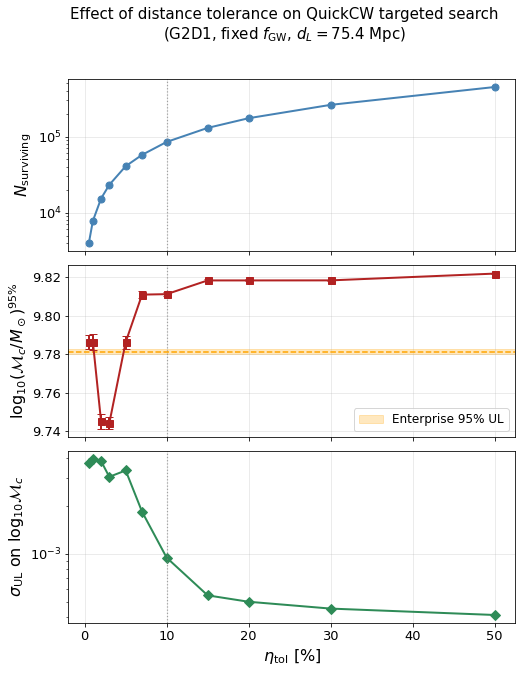

In [6]:
# ============================================================
# 4. Plot
# ============================================================
ntols     = np.array([r["ntol_pct"] for r in results])
n_survs   = np.array([r["n_surviving"] for r in results])
uls       = np.array([r["log10_mc_UL"] for r in results])
ul_errs   = np.array([r["log10_mc_UL_err"] for r in results])

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
fig.subplots_adjust(hspace=0.08)

# --- Panel 1: number of surviving samples ---
ax = axes[0]
ax.semilogy(ntols, n_survs, "o-", color="steelblue", lw=2, ms=7)
ax.set_ylabel(r"$N_{\rm surviving}$", fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
# Mark the 10% value used in the paper
ax.axvline(10, color="gray", ls=":", lw=1.2, alpha=0.7)
#ax.text(10.5, n_survs.max()*0.5, r"$\eta_{\rm tol}=10\%$", fontsize=12,
 #       color="gray", va="center")

# --- Panel 2: 95% UL on log10(Mc) ---
ax = axes[1]
valid = ~np.isnan(uls)
ax.errorbar(ntols[valid], uls[valid], yerr=ul_errs[valid],
            fmt="s-", color="firebrick", lw=2, ms=7, capsize=4)
ax.set_ylabel(r"$\log_{10}(\mathcal{M}_c / M_\odot)^{95\%}$", fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(10, color="gray", ls=":", lw=1.2, alpha=0.7)
# Enterprise comparison
if ent_mc_UL is not None:
    ax.axhspan(ent_mc_log_UL - ent_mc_log_UL_err,
               ent_mc_log_UL + ent_mc_log_UL_err,
               color="orange", alpha=0.25, label="Enterprise 95% UL")
    ax.axhline(ent_mc_log_UL, color="orange", ls="--", lw=1.5)
    ax.legend(fontsize=12, loc="lower right")

# --- Panel 3: UL error ---
ax = axes[2]
ax.semilogy(ntols[valid], ul_errs[valid], "D-", color="seagreen", lw=2, ms=7)
ax.set_ylabel(r"$\sigma_{\rm UL}$ on $\log_{10}\mathcal{M}_c$", fontsize=16)
ax.set_xlabel(r"$\eta_{\rm tol}$ [%]", fontsize=16)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(10, color="gray", ls=":", lw=1.2, alpha=0.7)

fig.suptitle("Effect of distance tolerance on QuickCW targeted search\n"
             f"(G2D1, fixed $f_{{\\rm GW}}$, $d_L = {TARGET_DL}$ Mpc)",
             fontsize=15, y=0.98)

outpath_pdf = "ntol_sweep_results.pdf"
outpath_png = "ntol_sweep_results.png"
fig.savefig(outpath_pdf, bbox_inches="tight", dpi=200)
fig.savefig(outpath_png, bbox_inches="tight", dpi=200)
print(f"\nFigure saved to {outpath_pdf} and {outpath_png}")




Figure saved to ntol_sweep_results.pdf and ntol_sweep_results.png


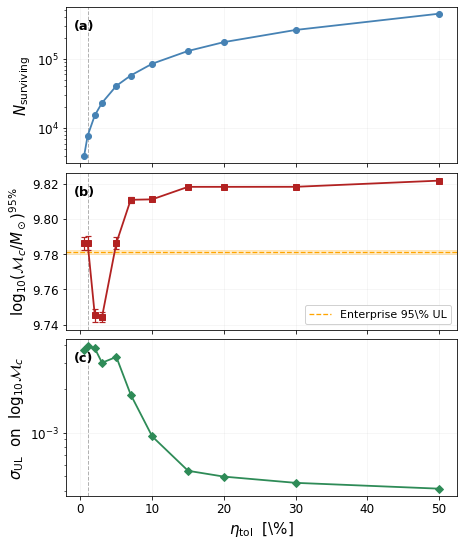

In [10]:
# ============================================================
# 4. Plot
# ============================================================
ntols     = np.array([r["ntol_pct"] for r in results])
n_survs   = np.array([r["n_surviving"] for r in results])
uls       = np.array([r["log10_mc_UL"] for r in results])
ul_errs   = np.array([r["log10_mc_UL_err"] for r in results])
valid     = ~np.isnan(uls)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True,
                         gridspec_kw={"hspace": 0.06})

# --- Panel 1: number of surviving samples ---
ax = axes[0]
ax.semilogy(ntols, n_survs, "o-", color="steelblue", lw=1.8, ms=6, zorder=3)
ax.set_ylabel(r"$N_{\rm surviving}$", fontsize=15)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.2, lw=0.5)
ax.axvline(1.0, color="gray", ls="--", lw=1.0, alpha=0.6)
#ax.text(1.3, n_survs[valid].max() * 0.35,
 #       r"$\eta_{\rm tol} = 1\%$" + "\n(this work)",
  #      fontsize=10, color="gray", va="center")

# --- Panel 2: 95% UL on log10(Mc) ---
ax = axes[1]
ax.errorbar(ntols[valid], uls[valid], yerr=ul_errs[valid],
            fmt="s-", color="firebrick", lw=1.8, ms=6, capsize=3,
            capthick=1.2, elinewidth=1.2, zorder=3)
ax.set_ylabel(r"$\log_{10}(\mathcal{M}_c / M_\odot)^{95\%}$", fontsize=15)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.2, lw=0.5)
ax.axvline(1.0, color="gray", ls="--", lw=1.0, alpha=0.6)
if ent_mc_UL is not None:
    ax.axhspan(ent_mc_log_UL - ent_mc_log_UL_err,
               ent_mc_log_UL + ent_mc_log_UL_err,
               color="orange", alpha=0.2, zorder=1)
    ax.axhline(ent_mc_log_UL, color="orange", ls="--", lw=1.3, zorder=2,
               label=r"Enterprise 95\% UL")
    ax.legend(fontsize=11, loc="lower right", framealpha=0.9)

# --- Panel 3: UL error ---
ax = axes[2]
ax.semilogy(ntols[valid], ul_errs[valid], "D-", color="seagreen",
            lw=1.8, ms=6, zorder=3)
ax.set_ylabel(r"$\sigma_{\rm UL}$  on  $\log_{10}\mathcal{M}_c$", fontsize=15)
ax.set_xlabel(r"$\eta_{\rm tol}$  [\%]", fontsize=15)
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.2, lw=0.5)
ax.axvline(1.0, color="gray", ls="--", lw=1.0, alpha=0.6)

# Panel labels
for i, label in enumerate(["(a)", "(b)", "(c)"]):
    axes[i].text(0.02, 0.92, label, transform=axes[i].transAxes,
                 fontsize=13, fontweight="bold", va="top")

outpath_pdf = "ntol_sweep_results.pdf"
outpath_png = "ntol_sweep_results.png"
fig.savefig(outpath_pdf, bbox_inches="tight", dpi=300)
fig.savefig(outpath_png, bbox_inches="tight", dpi=300)
print(f"\nFigure saved to {outpath_pdf} and {outpath_png}")

In [8]:
# ============================================================
# 5. Save CSV
# ============================================================
outpath_csv = "ntol_sweep_results.csv"
with open(outpath_csv, "w") as fout:
    fout.write("ntol_pct,n_surviving,frac_surviving,log10_mc_UL,log10_mc_UL_err\n")
    for r in results:
        fout.write(f"{r['ntol_pct']:.1f},{r['n_surviving']},"
                   f"{r['frac_surviving']:.6e},{r['log10_mc_UL']:.4f},"
                   f"{r['log10_mc_UL_err']:.4f}\n")
print(f"Table saved to {outpath_csv}")
print("\nDone.")

Table saved to ntol_sweep_results.csv

Done.
